# PCA Before K-Means: Does Dimensionality Reduction Improve Clustering?
## Improving K-Means Clustering with Principal Component Analysis (PCA)
### Irshad Patan – Student ID: 24147104

### Objective

In this tutorial, we investigate whether applying Principal Component Analysis (PCA) before K-Means clustering improves clustering performance and interpretability.

High-dimensional data often suffers from noise, redundancy, and the curse of dimensionality. PCA reduces dimensionality by projecting data onto directions of maximum variance. We explore whether this transformation leads to better cluster separation when using K-Means.

We compare:
- K-Means on original standardised data
- K-Means after PCA dimensionality reduction

Evaluation metrics:
- Inertia (within-cluster sum of squares)
- Silhouette score

### K-Means Clustering

K-Means is an unsupervised learning algorithm that partitions data into K clusters by minimising within-cluster variance.

The objective function is:

$$
\sum_{k=1}^{K} \sum_{x_i \in C_k} ||x_i - \mu_k||^2
$$

Where:
- \( C_k \) is cluster k
- \( \mu_k \) is the centroid of cluster k
- The algorithm iteratively updates cluster assignments and centroids.

Limitations:
- Sensitive to scaling
- Assumes spherical clusters
- Struggles in high-dimensional spaces

### Principal Component Analysis (PCA)

PCA is a dimensionality reduction technique that transforms data into a new coordinate system.

It:
- Computes the covariance matrix
- Finds eigenvectors (principal components)
- Projects data onto directions of maximum variance

The covariance matrix is defined as:

$$
\Sigma = \frac{1}{n} X^T X
$$

Each principal component explains a portion of total variance.

By reducing dimensions, PCA:
- Removes noise
- Reduces redundancy
- Improves visualisation
- Potentially improves clustering performance

In [12]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore", category=UserWarning)

### Load Dataset

We use the Wine dataset, which contains 13 chemical features extracted from wines belonging to three different cultivatrs.

Although labels exist, clustering is performed without using them.

### Load Data

In [13]:
wine = load_wine()
X = wine.data
y = wine.target  # Only used for reference

print("Dataset shape:", X.shape)

Dataset shape: (178, 13)


### Data Standardization

Both PCA and K-Means are sensitive to feature scale.

We standardize the data so that each feature has:
- Mean = 0
- Standard deviation = 1

In [14]:
# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Experiment 1: K-Means on Original Data

We apply K-Means directly to the scaled dataset using 3 clusters.

In [15]:
kmeans_original = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_original.fit(X_scaled)

labels_original = kmeans_original.labels_

inertia_original = kmeans_original.inertia_
silhouette_original = silhouette_score(X_scaled, labels_original)

print("Original Data Results:")
print("Inertia:", inertia_original)
print("Silhouette Score:", silhouette_original)

Original Data Results:
Inertia: 1277.928488844642
Silhouette Score: 0.2848589191898987


### Applying PCA

We now apply PCA to reduce dimensionality.

First, we examine how much variance is explained by each principal component.

In [22]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_

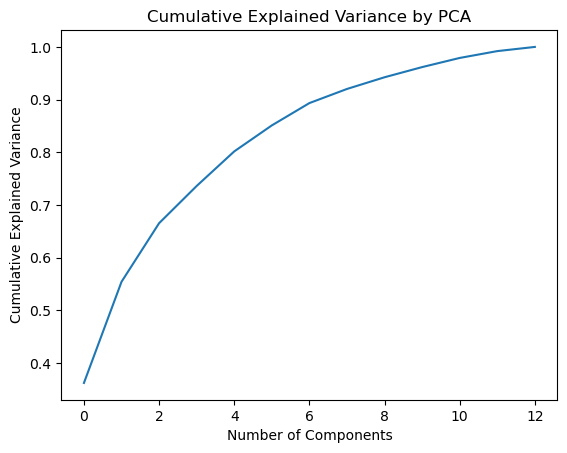

In [23]:
plt.figure()
plt.plot(np.cumsum(explained_variance))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance by PCA")
plt.show()

We now reduce the dataset to 2 principal components for clustering and visualisation.

In [24]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

### Experiment 2: K-Means After PCA

We now perform K-Means clustering on the 2D PCA representation.

In [19]:
kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_pca.fit(X_pca_2)

labels_pca = kmeans_pca.labels_

inertia_pca = kmeans_pca.inertia_
silhouette_pca = silhouette_score(X_pca_2, labels_pca)

print("After PCA Results:")
print("Inertia:", inertia_pca)
print("Silhouette Score:", silhouette_pca)

After PCA Results:
Inertia: 259.50938075119353
Silhouette Score: 0.5610505693103246


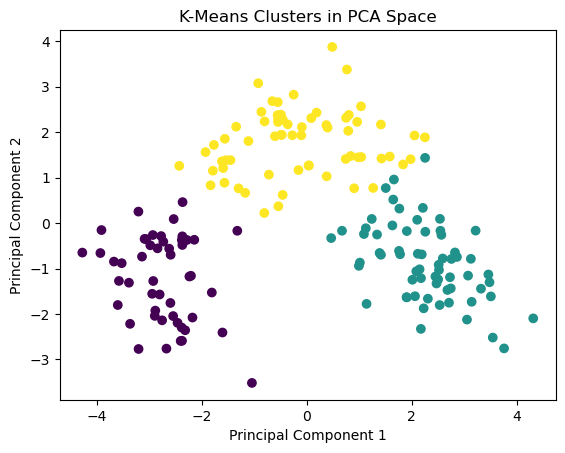

In [20]:
plt.figure()
plt.scatter(X_pca_2[:, 0], X_pca_2[:, 1], c=labels_pca)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters in PCA Space")
plt.show()

### Comparison of Results

We compare clustering performance before and after PCA.

In [21]:
#Comparison Table
comparison = pd.DataFrame({
    "Method": ["Original Data", "PCA (2 Components)"],
    "Inertia": [inertia_original, inertia_pca],
    "Silhouette Score": [silhouette_original, silhouette_pca]
})

comparison

,Method,Inertia,Silhouette Score
0,Original Data,1277.928489,0.284859
1,PCA (2 Components),259.509381,0.561051


### Discussion

Observations:

- PCA reduces dimensionality from 13 features to 2.
- Inertia changes due to projection into lower-dimensional space.
- Silhouette score indicates how well-separated clusters are.
- PCA may improve clustering if noise and redundant features are removed.
- However, excessive dimensionality reduction may cause information loss.

K-Means assumes spherical clusters and may not capture complex structures.

### Conclusion

This study examined whether applying PCA before K-Means improves clustering performance.

We found that:
- PCA significantly improves visual interpretability.
- Clustering performance can improve if redundant dimensions are removed.
- However, reducing dimensions too aggressively may degrade performance.

In practice, PCA is a powerful preprocessing step for clustering high-dimensional data.